In [2]:
import numpy as np
import matplotlib.pyplot as plt

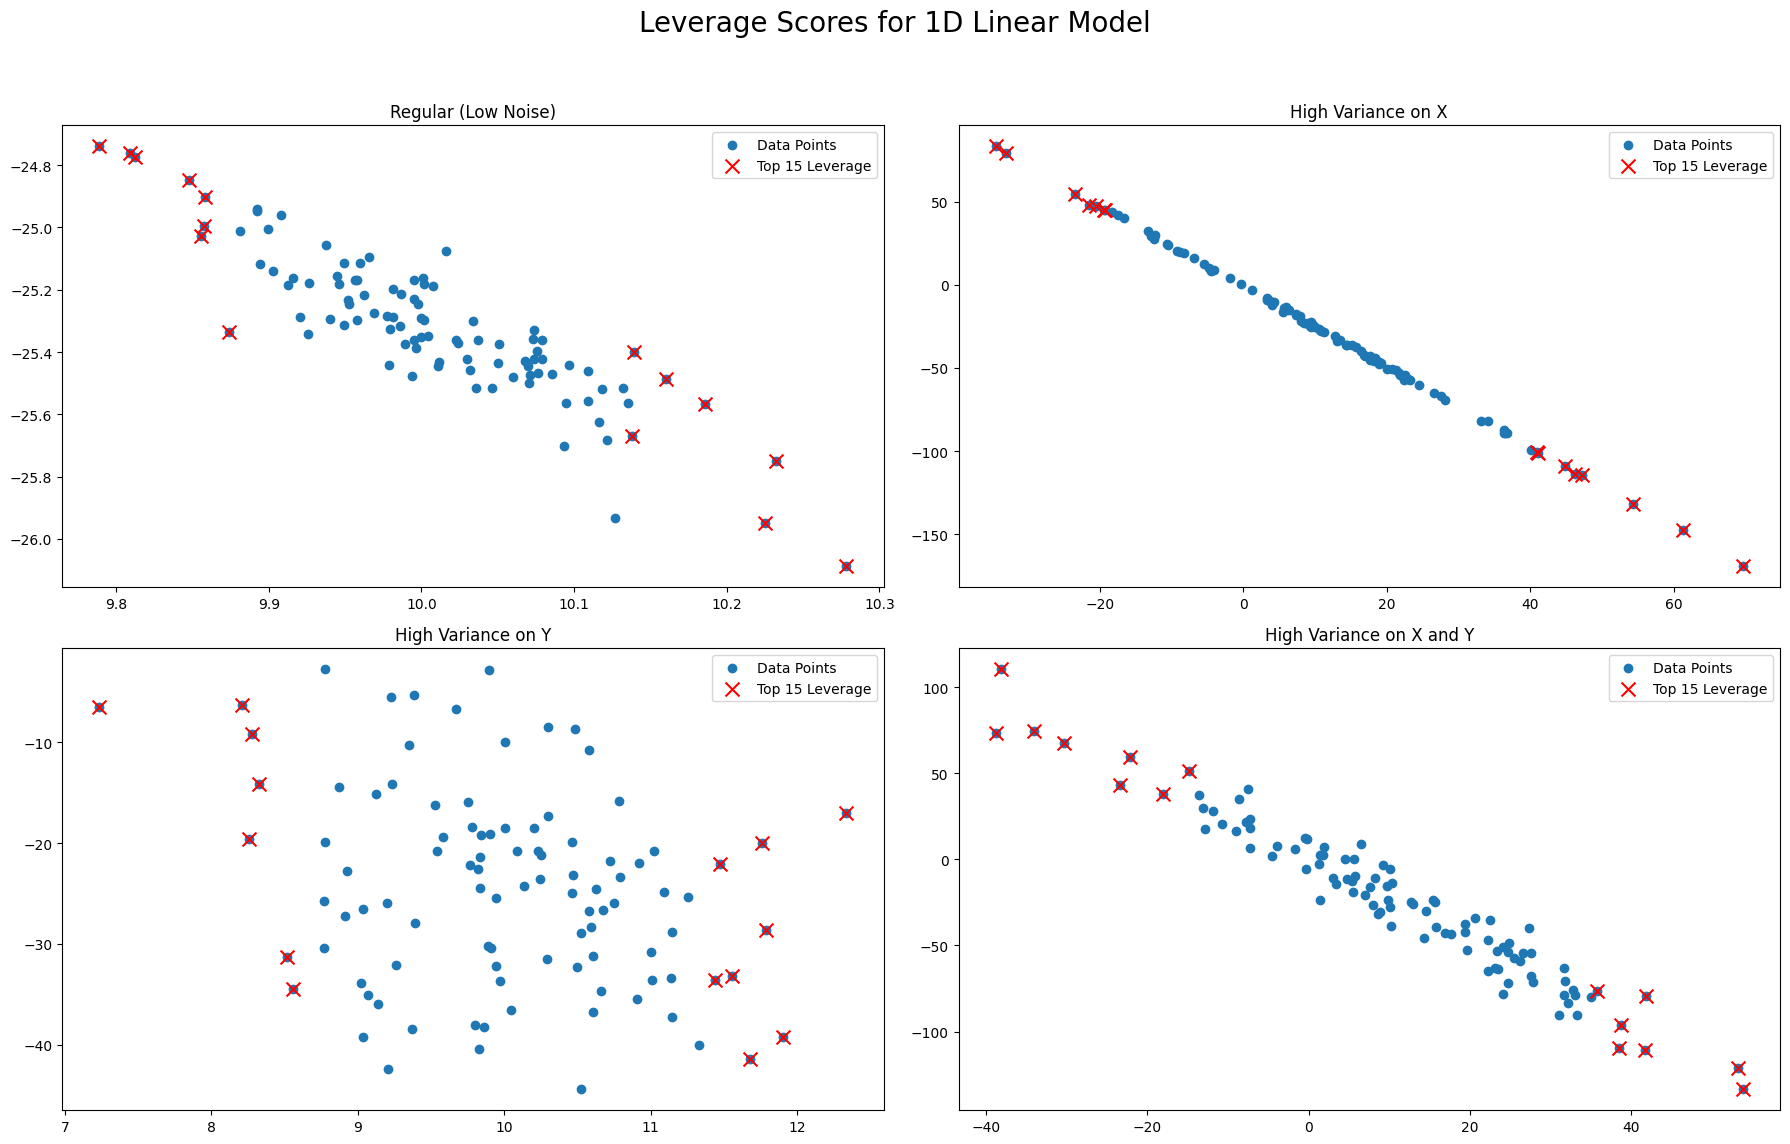

In [4]:
inf = 3
a = np.random.random() * inf * 2 - inf
b = np.random.random() * inf * 2 - inf

def generate_points(n, mu_noise, sigma_noise, mu_points, sigma_points):
    points = np.random.normal(mu_points, sigma_points, size=n)
    epsilon = np.random.normal(mu_noise, sigma_noise, size=n)
    return points, a * points + b + epsilon

def compute_leverage(x_points):
    X = np.vstack([x_points, np.ones(len(x_points))]).T

    H = X @ np.linalg.inv(X.T @ X) @ X.T
    return np.diag(H)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

cases = [
    {'title': "Regular (Low Noise)", 'n': 100, 'mu_n': 0, 'sig_n': 0.1, 'mu_p': 10, 'sig_p': 0.1},
    {'title': "High Variance on X", 'n': 100, 'mu_n': 0, 'sig_n': 1, 'mu_p': 10, 'sig_p': 20},
    {'title': "High Variance on Y", 'n': 100, 'mu_n': 0, 'sig_n': 10, 'mu_p': 10, 'sig_p': 1},
    {'title': "High Variance on X and Y", 'n': 100, 'mu_n': 0, 'sig_n': 10, 'mu_p': 10, 'sig_p': 20}
]

for ax, case in zip(axes, cases):
    x, y = generate_points(case['n'], case['mu_n'], case['sig_n'], case['mu_p'], case['sig_p'])
    leverage = compute_leverage(x)

    top_k = 15
    high_leverage_indices = np.argsort(leverage)[-top_k:]

    ax.scatter(x, y, label='Data Points')
    ax.scatter(x[high_leverage_indices], y[high_leverage_indices],
               color='red', marker='x', s=100, label=f'Top {top_k} Leverage')

    ax.set_title(case['title'])
    ax.legend()

plt.suptitle("Leverage Scores for 1D Linear Model", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

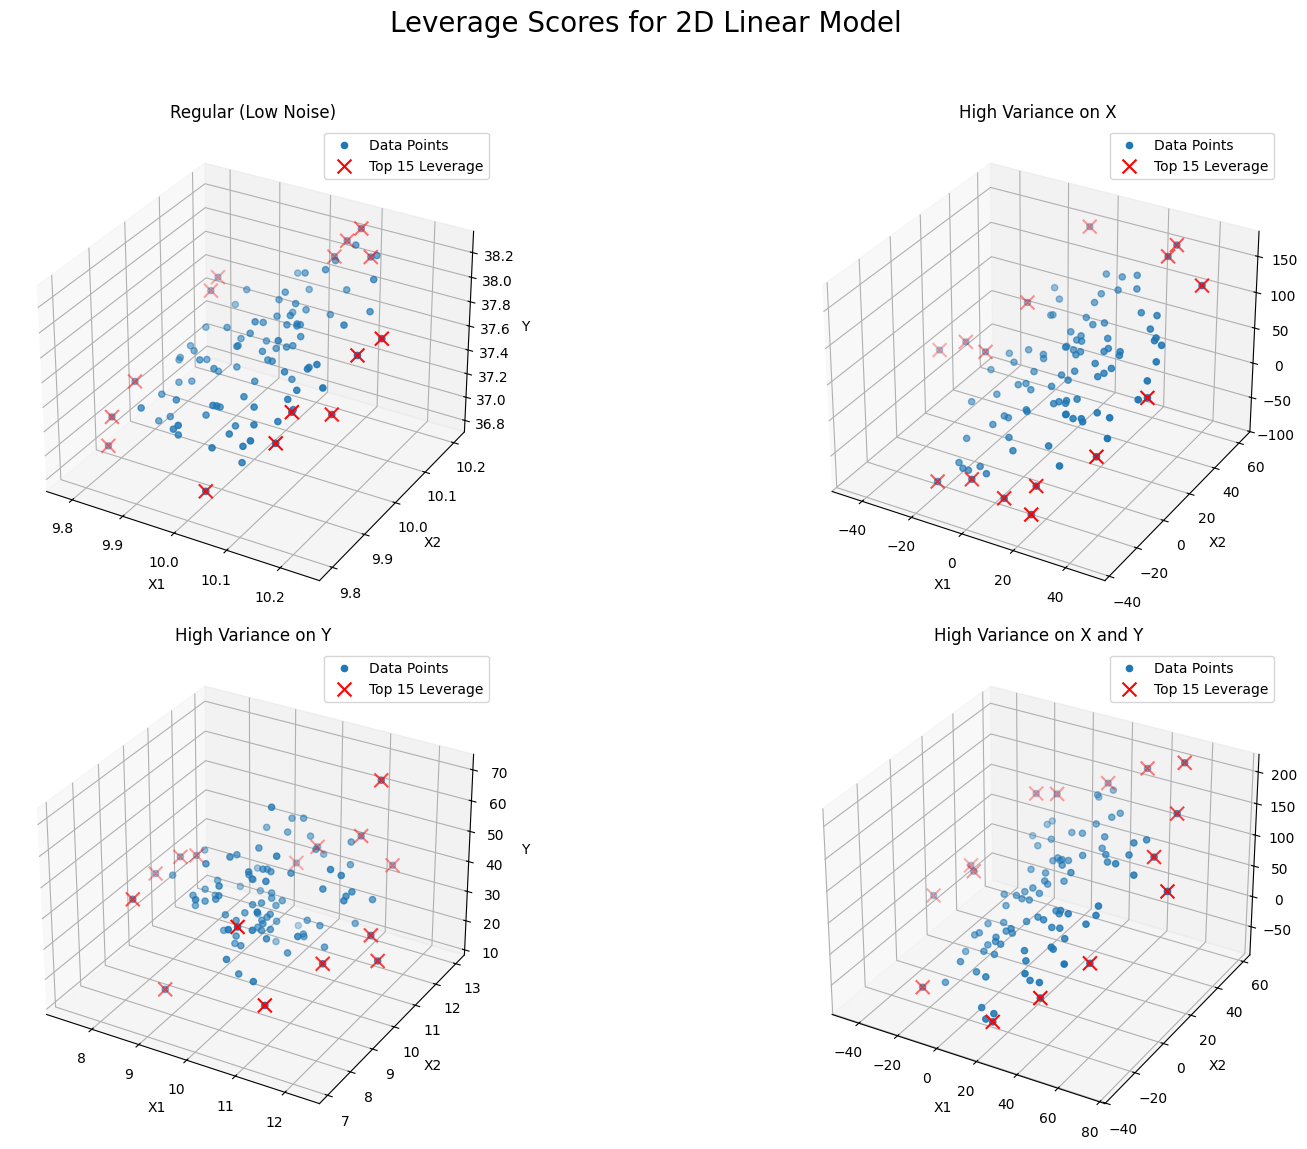

In [5]:
a_2d = np.random.random() * inf * 2 - inf
b_2d = np.random.random() * inf * 2 - inf
c_2d = np.random.random() * inf * 2 - inf

def generate_points_2d(n, mu_noise, sigma_noise, mu_points, sigma_points):
    x1 = np.random.normal(mu_points, sigma_points, size=n)
    x2 = np.random.normal(mu_points, sigma_points, size=n)

    epsilon = np.random.normal(mu_noise, sigma_noise, size=n)
    y = a_2d * x1 + b_2d * x2 + c_2d + epsilon
    return x1, x2, y

def compute_leverage_2d(x1_points, x2_points):
    X = np.vstack([x1_points, x2_points, np.ones(len(x1_points))]).T

    H = X @ np.linalg.inv(X.T @ X) @ X.T
    return np.diag(H)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 12))

cases_2d = [
    {'title': "Regular (Low Noise)", 'n': 100, 'mu_n': 0, 'sig_n': 0.1, 'mu_p': 10, 'sig_p': 0.1},
    {'title': "High Variance on X", 'n': 100, 'mu_n': 0, 'sig_n': 1, 'mu_p': 10, 'sig_p': 20},
    {'title': "High Variance on Y", 'n': 100, 'mu_n': 0, 'sig_n': 10, 'mu_p': 10, 'sig_p': 1},
    {'title': "High Variance on X and Y", 'n': 100, 'mu_n': 0, 'sig_n': 10, 'mu_p': 10, 'sig_p': 20}
]

for i, case in enumerate(cases_2d):
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')

    x1, x2, y = generate_points_2d(case['n'], case['mu_n'], case['sig_n'], case['mu_p'], case['sig_p'])
    leverage = compute_leverage_2d(x1, x2)

    top_k = 15
    high_leverage_indices = np.argsort(leverage)[-top_k:]

    ax.scatter(x1, x2, y, label='Data Points')
    ax.scatter(x1[high_leverage_indices], x2[high_leverage_indices], y[high_leverage_indices],
               color='red', marker='x', s=100, label=f'Top {top_k} Leverage')

    ax.set_title(case['title'])
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('Y')
    ax.legend()

plt.suptitle("Leverage Scores for 2D Linear Model", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [7]:
%pip install pyod
from pyod.utils.data import generate_data_clusters

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/pyod/models/base.py:554: UserWarning: y should not be presented in unsupervised learning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/pyod/models/base.py:554: UserWarning: y should not be presented in unsupervised learning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/pyod/models/base.py:554: UserWarning: y should not be presented in unsupervised learning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/d

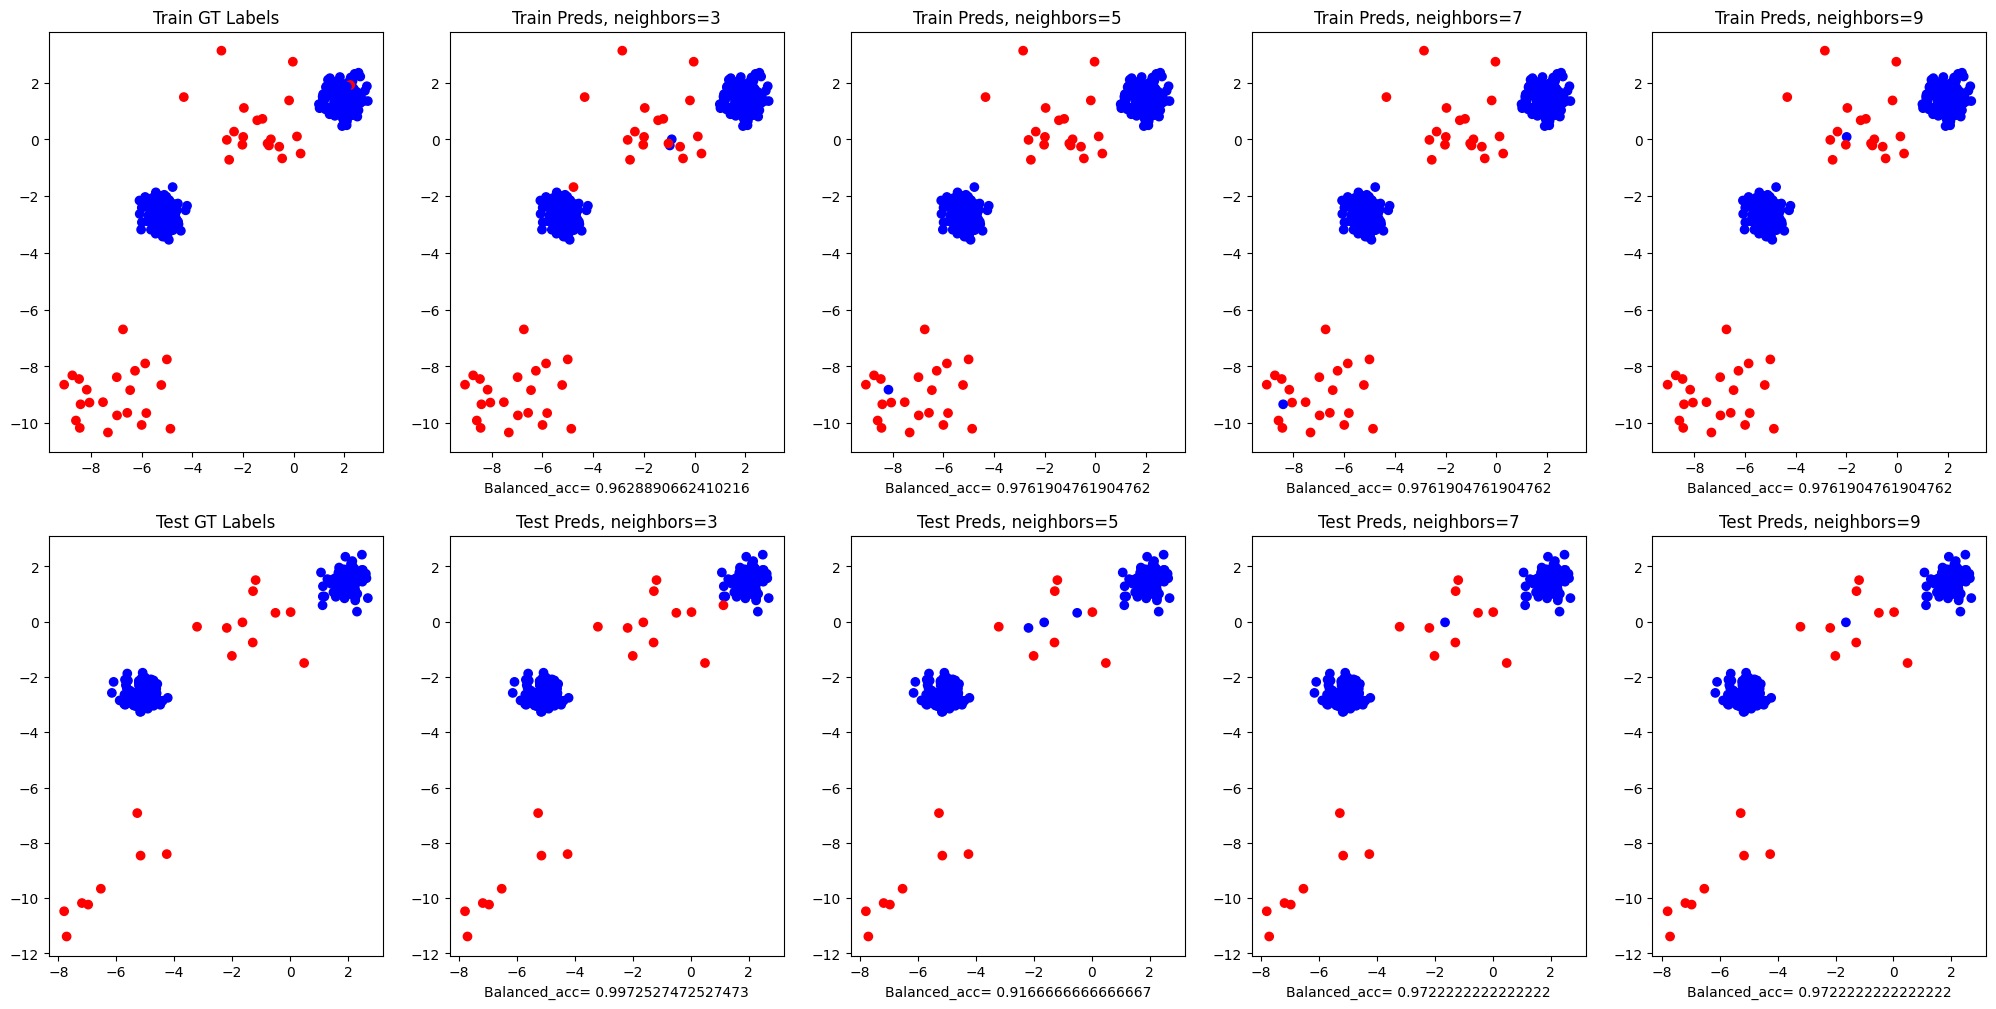

In [14]:
from pyod.models.knn import KNN
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, roc_curve

x_train, x_test, y_train, y_test = generate_data_clusters(400, 200, 2, 2, 0.1)

fig, axes = plt.subplots(2, 5, figsize=(25, 12))
axes = axes.flatten()

c_train = ['red' if l == 1 else 'blue' for l in y_train]
c_test = ['red' if l == 1 else 'blue' for l in y_test]

train = 0
test = 5
axes[train].scatter(x_train[:, 0], x_train[:, 1], c=c_train)
axes[train].set_title("Train GT Labels")

axes[test].scatter(x_test[:, 0], x_test[:, 1], c=c_test)
axes[test].set_title("Test GT Labels")

for n in [3,5,7,9]:
  model = KNN(contamination= 0.1, n_neighbors=n)
  y_pred_train = model.fit_predict(x_train, y_train)
  y_pred_test = model.predict(x_test)

  cp_train = ['red' if l == 1 else 'blue' for l in y_pred_train]
  cp_test = ['red' if l == 1 else 'blue' for l in y_pred_test]

  bal_acc_train = balanced_accuracy_score(y_train, y_pred_train)
  bal_acc_test = balanced_accuracy_score(y_test, y_pred_test)
  train += 1
  test += 1

  axes[train].scatter(x_train[:, 0], x_train[:, 1], c=cp_train)
  axes[train].set_title(f"Train Preds, neighbors={n}")
  axes[train].set_xlabel(f"Balanced_acc= {bal_acc_train}")

  axes[test].scatter(x_test[:, 0], x_test[:, 1], c=cp_test)
  axes[test].set_title(f"Test Preds, neighbors={n}")
  axes[test].set_xlabel(f"Balanced_acc= {bal_acc_test}")

plt.show()

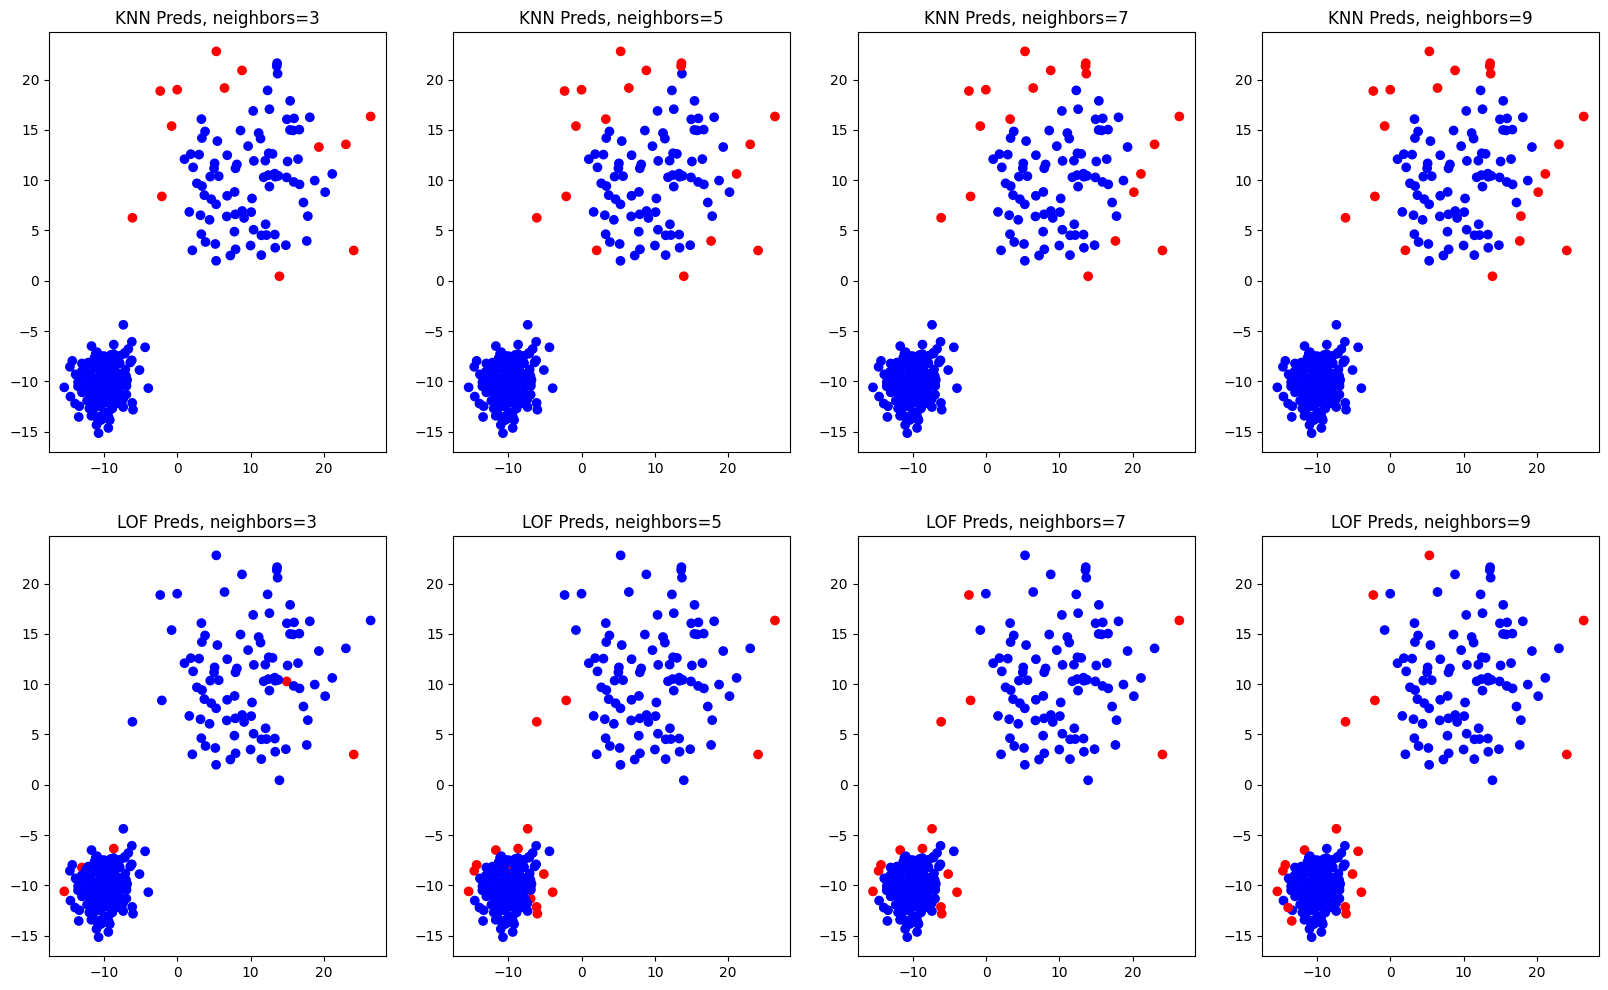

In [19]:
from sklearn.datasets import make_blobs
from pyod.models.lof import LOF

x1, _ = make_blobs(n_samples=200, centers=[(-10, -10)], cluster_std=2.0, n_features=2)
x2, _ = make_blobs(n_samples=100, centers=[(10, 10)], cluster_std=6.0, n_features=2)

x = np.concatenate((x1, x2))

cont = 0.07

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

knn = 0
lof = 4

for n in [3,5,7,9]:
  model_knn = KNN(contamination= cont, n_neighbors=n)
  model_lof = LOF(contamination= cont, n_neighbors=n)

  model_knn.fit(x)
  y_pred_test_knn = model_knn.predict(x)

  model_lof.fit(x)
  y_pred_test_lof = model_lof.predict(x)

  cp_knn = ['red' if l == 1 else 'blue' for l in y_pred_test_knn]
  cp_lof = ['red' if l == 1 else 'blue' for l in y_pred_test_lof]

  axes[knn].scatter(x[:, 0], x[:, 1], c=cp_knn)
  axes[knn].set_title(f"KNN Preds, neighbors={n}")

  axes[lof].scatter(x[:, 0], x[:, 1], c=cp_lof)
  axes[lof].set_title(f"LOF Preds, neighbors={n}")
  knn += 1
  lof += 1

plt.show()

In [23]:
%pip install combo
import scipy.io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pyod.utils.utility import standardizer
from pyod.models.combination import average, maximization

In [42]:
mat = scipy.io.loadmat('/content/cardio.mat')

x = mat['X']
y = mat['y'].ravel()

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

cont = (y_train == 1).sum() / (y_train == 0).sum()

neighbors = [60, 70, 80, 90, 100, 110, 120, 130, 140, 150]

train_scores = []
test_scores = []

for i, n in enumerate(neighbors):
  model_knn = KNN(contamination= cont, n_neighbors=n)

  y_pred_train = model_knn.fit_predict(x_train)
  y_pred_test = model_knn.predict(x_test)

  train_scores.append(model_knn.decision_function(x_train))
  test_scores.append(model_knn.decision_function(x_test))

  print(f"Neighbors = {n}, BA_train = {balanced_accuracy_score(y_train, y_pred_train)}, BA_test = {balanced_accuracy_score(y_test, y_pred_test)}")

train_scores_norm, test_scores_norm = standardizer(np.array(train_scores).T, np.array(test_scores).T)

scores_avg_train = average(train_scores_norm)
scores_avg_test = average(test_scores_norm)

scores_max_train = maximization(train_scores_norm)
scores_max_test = maximization(test_scores_norm)

threshold_avg = np.quantile(scores_avg_train, 1 - cont)
threshold_max = np.quantile(scores_max_train, 1 - cont)

y_pred_avg = (scores_avg_test > threshold_avg).astype(int)
y_pred_max = (scores_max_test > threshold_max).astype(int)

print(f"BA average: {balanced_accuracy_score(y_test, y_pred_avg)}")
print(f"BA max: {balanced_accuracy_score(y_test, y_pred_max)}")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)


Neighbors = 60, BA_train = 0.7605522557816251, BA_test = 0.7066740063019628


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)


Neighbors = 70, BA_train = 0.7785395341000042, BA_test = 0.7076800425192665


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)


...

Neighbors = 130, BA_train = 0.7965268124183833, BA_test = 0.7548498538400212


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)


Neighbors = 140, BA_train = 0.801023631997978, BA_test = 0.7548498538400212


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)


Neighbors = 150, BA_train = 0.801023631997978, BA_test = 0.7642838161041722
BA average: 0.7538438176227173
BA max: 0.7727117421510192
